- Data Cleaning

# Prepare Before Start

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/SessionsPapers.csv")
df_copy = df.copy()

print("Data sample : ")
print(df.sample(5))

Data sample : 
         paper_id    year      date        trial_id offenceCategory  \
153473  t18621027     NaN  18621027  t18621027-1048   royalOffences   
4750     16950508  1695.0  16950508    t16950508-41   royalOffences   
10737    17211011  1721.0  17211011    t17211011-19           theft   
173564  t18841020     NaN  18841020  t18841020-1063          sexual   
114297  t18400817     NaN  18400817  t18400817-1924           theft   

        offenceSubcategory verdictCategory punishmentCategory crime_locations  \
153473     coiningOffences          guilty           imprison             NaN   
4750       coiningOffences       notGuilty                NaN   Christ-Church   
10737       theftFromPlace          guilty          transport       Isleworth   
173564                rape          guilty           imprison             NaN   
114297  stealingFromMaster          guilty           imprison             NaN   

                    defendant_names defendant_genders  num_defendants  

/tmp/ipykernel_464/322808008.py:4: DtypeWarning: Columns (0,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/SessionsPapers.csv")


In [ ]:
print("Data info : ")
df.info()

Data info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197751 entries, 0 to 197750
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   paper_id            197751 non-null  object 
 1   year                99637 non-null   float64
 2   date                197751 non-null  int64  
 3   trial_id            197751 non-null  object 
 4   offenceCategory     197695 non-null  object 
 5   offenceSubcategory  197695 non-null  object 
 6   verdictCategory     197445 non-null  object 
 7   punishmentCategory  146137 non-null  object 
 8   crime_locations     62875 non-null   object 
 9   defendant_names     197023 non-null  object 
 10  defendant_genders   197728 non-null  object 
 11  num_defendants      197751 non-null  int64  
 12  num_victims         197751 non-null  int64  
 13  num_offences        197751 non-null  int64  
 14  num_verdicts        197751 non-null  int64  
 15  num_punishments     1

In [ ]:
print("Data describe : ")
print(df.describe())

Data describe : 
               year          date  num_defendants    num_victims  \
count  99637.000000  1.977510e+05   197751.000000  197751.000000   
mean    1784.086113  1.823843e+07        1.244469       1.026751   
std       43.017261  5.292681e+05        0.650871       0.715416   
min     1674.000000  1.674043e+07        0.000000       0.000000   
25%     1752.000000  1.795103e+07        1.000000       1.000000   
50%     1796.000000  1.834052e+07        1.000000       1.000000   
75%     1821.000000  1.857082e+07        1.000000       1.000000   
max     1834.000000  1.913040e+07       35.000000      35.000000   

        num_offences   num_verdicts  num_punishments  
count  197751.000000  197751.000000    197751.000000  
mean        1.067560       1.133122         0.848243  
std         0.331044       0.429603         0.619195  
min         0.000000       0.000000         0.000000  
25%         1.000000       1.000000         0.000000  
50%         1.000000       1.000000     

In [ ]:
df = df.drop(columns=["trial_id", "paper_id", "year"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197751 entries, 0 to 197750
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date                197751 non-null  int64 
 1   offenceCategory     197695 non-null  object
 2   offenceSubcategory  197695 non-null  object
 3   verdictCategory     197445 non-null  object
 4   punishmentCategory  146137 non-null  object
 5   crime_locations     62875 non-null   object
 6   defendant_names     197023 non-null  object
 7   defendant_genders   197728 non-null  object
 8   num_defendants      197751 non-null  int64 
 9   num_victims         197751 non-null  int64 
 10  num_offences        197751 non-null  int64 
 11  num_verdicts        197751 non-null  int64 
 12  num_punishments     197751 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 19.6+ MB
None


- Manage dtype

# manage date

In [ ]:
# perfect date
df["date"] = df["date"].astype(str)

df["year"] = df["date"].str[:4].astype(int)
df["month"] = df["date"].str[4:6].astype(int)
df["day"] = df["date"].str[6:].astype(int)

print(df["year"].head(5))
print(df.info())

0    1674
1    1674
2    1674
3    1674
4    1674
Name: year, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197751 entries, 0 to 197750
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date                197751 non-null  object
 1   offenceCategory     197695 non-null  object
 2   offenceSubcategory  197695 non-null  object
 3   verdictCategory     197445 non-null  object
 4   punishmentCategory  146137 non-null  object
 5   crime_locations     62875 non-null   object
 6   defendant_names     197023 non-null  object
 7   defendant_genders   197728 non-null  object
 8   num_defendants      197751 non-null  int64 
 9   num_victims         197751 non-null  int64 
 10  num_offences        197751 non-null  int64 
 11  num_verdicts        197751 non-null  int64 
 12  num_punishments     197751 non-null  int64 
 13  year                197751 non-null  int64 
 14  month               19775

# **manage category column**

In [ ]:
# to Category
cat_cols = [
    'offenceCategory',
    'offenceSubcategory',
    'verdictCategory',
    'punishmentCategory',
    'defendant_genders'
]

for col in cat_cols:
    print(f"📌 Column: {col}")
    print(f"nunique category : {df[col].nunique()}")
    print("=" * 30 + "\n")
    print(df[col].value_counts(dropna=False).head(15))
    print("=" * 40 + "\n")

📌 Column: offenceCategory
nunique category : 9

offenceCategory
theft            141703
deception         13652
royalOffences     10439
violentTheft       8418
breakingPeace      7386
sexual             6865
kill               5170
miscellaneous      3067
damage              995
NaN                  56
Name: count, dtype: int64

📌 Column: offenceSubcategory
nunique category : 56

offenceSubcategory
grandLarceny          39367
simpleLarceny         28675
theftFromPlace        14280
pocketpicking         13403
coiningOffences        9989
stealingFromMaster     9681
burglary               9558
fraud                  6038
forgery                5793
receiving              5320
wounding               5303
other                  5129
robbery                4702
embezzlement           4587
animalTheft            3911
Name: count, dtype: int64

📌 Column: verdictCategory
nunique category : 4

verdictCategory
guilty            141732
notGuilty          55102
miscVerdict          478
NaN         

#

#1. manage punishmentCategory

In [ ]:
# manage punishmentCategory
print("check relation between verdictCategory and punishmentCategory : \n")

print(pd.crosstab(df['verdictCategory'], df['punishmentCategory'].fillna('MISSING')))
print("-" * 50)
df['punishmentCategory'] = df['punishmentCategory'].fillna('none')

print("result after cleaning : \n")
print(df['punishmentCategory'].value_counts(dropna=False))

check relation between verdictCategory and punishmentCategory : 

punishmentCategory  MISSING  corporal  death  imprison  miscPunish  noPunish  \
verdictCategory                                                                
guilty                 3067      7443   9416     69235       10621      4431   
miscVerdict             298         1      0       150          18        10   
notGuilty             48037       303    809      3069         528       226   
specialVerdict          123         1      4         3           0         2   

punishmentCategory  transport  
verdictCategory                
guilty                  37519  
miscVerdict                 1  
notGuilty                2130  
specialVerdict              0  
--------------------------------------------------
result after cleaning : 

punishmentCategory
imprison      72589
none          51614
transport     39671
miscPunish    11193
death         10250
corporal       7760
noPunish       4674
Name: count, dtype: int64

In [ ]:
print(f"📦 จำนวนข้อมูลก่อนทำความสะอาดขั้นสุดท้าย: {len(df)} แถว")

# 1. อุดรูรั่ว: เติม NaN ใน punishmentCategory ด้วยคำว่า 'none'
df['punishmentCategory'] = df['punishmentCategory'].fillna('none')

# 2. ลบ "คดีผีหลอก": ไม่มีจำเลย หรือ ไม่มีข้อหา
ghost_mask = (df['num_defendants'] < 1) | (df['num_offences'] < 1)

# 3. ลบ "รอดแต่โดนลงโทษ": notGuilty แต่มีบทลงโทษ (คดีซ้อนคดี)
real_punish = ['death', 'imprison', 'transport', 'corporal', 'miscPunish']
conflict_mask = (df['verdictCategory'] == 'notGuilty') & (df['punishmentCategory'].isin(real_punish))

# 4. ลบ "ผิดแต่ไร้โทษ": guilty แต่เป็น none (ลืมจด) 👉👉 [เพิ่มเงื่อนไขนี้ตามที่คุณทักมาครับ!]
guilty_no_punish_mask = (df['verdictCategory'] == 'guilty') & (df['punishmentCategory'] == 'none')

# 5. รวมร่างการลบทิ้งทั้งหมด (ใช้เครื่องหมาย | คือ OR) และแถม Drop ค่า NaN เล็กๆ น้อยๆ
mask_to_drop = ghost_mask | conflict_mask | guilty_no_punish_mask
df_clean = df[~mask_to_drop].dropna(subset=['offenceCategory', 'verdictCategory']).copy()

# 6. เช็คความสะอาด
print(f"✅ จำนวนข้อมูลหลังทำความสะอาด: {len(df_clean)} แถว")
print("-" * 50)
print("📊 เช็คความสมบูรณ์คำตัดสิน vs บทลงโทษ (ต้องไม่มี guilty + none และ notGuilty + โทษจริง):")
print(pd.crosstab(df_clean['verdictCategory'], df_clean['punishmentCategory']))

📦 จำนวนข้อมูลก่อนทำความสะอาดขั้นสุดท้าย: 197751 แถว
✅ จำนวนข้อมูลหลังทำความสะอาด: 187485 แถว
--------------------------------------------------
📊 เช็คความสมบูรณ์คำตัดสิน vs บทลงโทษ (ต้องไม่มี guilty + none และ notGuilty + โทษจริง):
punishmentCategory  corporal  death  imprison  miscPunish  noPunish   none  \
verdictCategory                                                              
guilty                  7438   9414     69228       10619      4427      0   
miscVerdict                1      0       149          18        10    298   
notGuilty                  0      0         0           0       225  48024   
specialVerdict             1      4         3           0         2    123   

punishmentCategory  transport  
verdictCategory                
guilty                  37500  
miscVerdict                 1  
notGuilty                   0  
specialVerdict              0  


#2. manage Defendant_genders

In [ ]:
# 1. นับจำนวนชายและหญิงอย่างแม่นยำด้วย Regex (\b คือการครอบคำไม่ให้ไปนับคำที่ซ้อนกัน)
df_clean['num_male'] = df_clean['defendant_genders'].str.count(r'\bmale\b').fillna(0).astype(int)
df_clean['num_female'] = df_clean['defendant_genders'].str.count(r'\bfemale\b').fillna(0).astype(int)

# 2. กำหนดเงื่อนไขสำหรับการจัดกลุ่ม (Gender Group)
conditions = [
    (df_clean['num_male'] > 0) & (df_clean['num_female'] > 0),  # มีทั้งคู่ = mixed
    (df_clean['num_male'] > 0) & (df_clean['num_female'] == 0), # ชายล้วน = male_only
    (df_clean['num_male'] == 0) & (df_clean['num_female'] > 0)  # หญิงล้วน = female_only
]
choices = ['mixed', 'male_only', 'female_only']

# 3. สร้างคอลัมน์ gender_group ด้วยเงื่อนไขด้านบน (ถ้าไม่เข้าเงื่อนไขเลยให้เป็น unknown)
df_clean['gender_group'] = np.select(conditions, choices, default='unknown')

# 4. แปลง Data Type เพื่อประหยัด Memory
df_clean['gender_group'] = df_clean['gender_group'].astype('category')

# (ออปชันเสริม: หากต้องการลบ defendant_genders คอลัมน์เก่าทิ้ง ให้เอา # ออก)
# df_clean = df_clean.drop(columns=['defendant_genders'])

# 5. เช็คผลลัพธ์ความเป๊ะ!
print("✅ 1. สรุปกลุ่มเพศจำเลย (นับตามจำนวนคดี):")
print(df_clean['gender_group'].value_counts(dropna=False))
print("-" * 50)

# --- ส่วนที่เพิ่มเข้ามาใหม่ ---
print("👥 2. สรุปจำนวนประชากรจำเลยทั้งหมด (นับรายบุคคล):")
print(f"👨 จำนวนจำเลยชายทั้งหมด (Total Males): {df_clean['num_male'].sum():,} คน")
print(f"👩 จำนวนจำเลยหญิงทั้งหมด (Total Females): {df_clean['num_female'].sum():,} คน")
print(f"❓ จำนวนคดีที่ไม่ระบุเพศ (Unknown): {(df_clean['gender_group'] == 'unknown').sum():,} คดี")
print("-" * 50)

print("🔍 3. แอบดูข้อมูล 5 แถวแรกว่านับเลขถูกไหม:")
print(df_clean[['gender_group', 'num_male', 'num_female']].head())

✅ 1. สรุปกลุ่มเพศจำเลย (นับตามจำนวนคดี):
gender_group
male_only      144027
female_only     38461
mixed            4899
unknown            98
Name: count, dtype: int64
--------------------------------------------------
👥 2. สรุปจำนวนประชากรจำเลยทั้งหมด (นับรายบุคคล):
👨 จำนวนจำเลยชายทั้งหมด (Total Males): 177,177 คน
👩 จำนวนจำเลยหญิงทั้งหมด (Total Females): 48,108 คน
❓ จำนวนคดีที่ไม่ระบุเพศ (Unknown): 98 คดี
--------------------------------------------------
🔍 3. แอบดูข้อมูล 5 แถวแรกว่านับเลขถูกไหม:
  gender_group  num_male  num_female
1    male_only         1           0
3    male_only         1           0
4  female_only         0           1
8      unknown         0           0
9    male_only         1           0


#3. manage verdictCategory

In [ ]:
df_clean['verdictCategory'] = df_clean['verdictCategory'].astype(str).replace(
    ['miscVerdict', 'specialVerdict'], 'other'
).astype('category')

df_clean["verdictCategory"].value_counts()

,count
verdictCategory,
guilty,138626
notGuilty,48249
other,610


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187485 entries, 1 to 197750
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   date                187485 non-null  object  
 1   offenceCategory     187485 non-null  object  
 2   offenceSubcategory  187485 non-null  object  
 3   verdictCategory     187485 non-null  category
 4   punishmentCategory  187485 non-null  object  
 5   crime_locations     59233 non-null   object  
 6   defendant_names     186955 non-null  object  
 7   defendant_genders   187485 non-null  object  
 8   num_defendants      187485 non-null  int64   
 9   num_victims         187485 non-null  int64   
 10  num_offences        187485 non-null  int64   
 11  num_verdicts        187485 non-null  int64   
 12  num_punishments     187485 non-null  int64   
 13  year                187485 non-null  int64   
 14  month               187485 non-null  int64   
 15  day                 18

# manage defendant_names

In [ ]:
print(df_clean["defendant_names"].sample(50))

135733                       TYLER MARIA
29105                     Armstrong John
159070                     MURRAY ANDREW
19141                        Wilson Owen
89071                      NOWLAND JAMES
42147                       OXEN MICHAEL
54021                          GWYN JOHN
16617                     Lugg Elizabeth
2671                          Dukes Mary
102055                 FENNING ELIZABETH
75351                      LIMEN WILLIAM
157763       WEST EDWARD, INGHAM WILLIAM
15404                   Feuterel Richard
18954                  Newington William
115189                MATTHEWS CATHERINE
141857                      JOHNSON JOHN
27784                      Weech Rebecca
102960                      BARNES JAMES
44049                    GRIFFITH ROBERT
193319              ANDERSON JOHN JARVIS
73899                     BARBER CHARLES
74560                       JONES SAMUEL
21807                        Levi Samuel
121412                         WARD CAIN
99891           

In [ ]:
import pandas as pd
import re

def clean_defendant_names(name_str):
    # 1. จัดการค่าว่าง (Null) ให้เป็นคำว่า 'Unknown'
    if pd.isna(name_str) or str(name_str).strip() == '':
        return 'Unknown'

    # 2. แปลงเป็นตัวอักษรพิมพ์เล็ก แล้วทำให้ตัวแรกของทุกคำเป็นตัวพิมพ์ใหญ่ (Title Case)
    # เช่น 'PARKER GEORGE' -> 'Parker George'
    name_str = str(name_str).title()

    # 3. แยกชื่อด้วยลูกน้ำ (กรณีมีจำเลยหลายคน)
    names = name_str.split(',')

    cleaned_names = []
    for n in names:
        # 4. ลบช่องว่างส่วนเกิน (เช่น เคาะเบิ้ลตรงกลาง) และตัดช่องว่างซ้าย/ขวา
        clean_n = re.sub(r'\s+', ' ', n).strip()
        if clean_n:
            cleaned_names.append(clean_n)

    # 5. เรียงลำดับชื่อตามตัวอักษร (A-Z) เพื่อป้องกันปัญหาการพิมพ์ชื่อจำเลยสลับตำแหน่งกัน
    cleaned_names.sort()

    # 6. จับมัดรวมกันคืนด้วยเครื่องหมาย ', ' ให้สวยงาม
    return ', '.join(cleaned_names)

# --- วิธีนำไปใช้งาน ---
# df['defendant_names_clean'] = df['defendant_names'].apply(clean_defendant_names)

# ลองรันดูผลลัพธ์กับข้อมูลตัวอย่าง
sample_names = [
    "Cook Katharine",
    "PARKER GEORGE",
    "BARTON FREDERICK, BARTON THOMAS",
    "HAYES ROBERT, STEVENS GEORGE, STEVENS CATHERINE",
    " WILSON HENRY , WHITTINGHAM JOHN " # ทดสอบสลับที่และมีช่องว่างเกิน
]

print("ตัวอย่างผลลัพธ์หลัง Clean:")
print("-" * 50)
for name in sample_names:
    print(f"Original : {name}")
    print(f"Cleaned  : {clean_defendant_names(name)}\n")

ตัวอย่างผลลัพธ์หลัง Clean:
--------------------------------------------------
Original : Cook Katharine
Cleaned  : Cook Katharine

Original : PARKER GEORGE
Cleaned  : Parker George

Original : BARTON FREDERICK, BARTON THOMAS
Cleaned  : Barton Frederick, Barton Thomas

Original : HAYES ROBERT, STEVENS GEORGE, STEVENS CATHERINE
Cleaned  : Hayes Robert, Stevens Catherine, Stevens George

Original :  WILSON HENRY , WHITTINGHAM JOHN 
Cleaned  : Whittingham John, Wilson Henry



In [ ]:
# 1. ลบแถวที่ไม่มีชื่อจำเลยทิ้งไปเลย
df_clean = df_clean.dropna(subset=['defendant_names'])

# 2. คลีนชื่อจำเลยให้สวยงามตาม Function ที่เราเขียนไว้ก่อนหน้านี้
df_clean['defendant_names_clean'] = df_clean['defendant_names'].apply(clean_defendant_names)

# เช็กความสะอาดรอบสุดท้าย
print("ยอดค่าว่างปัจจุบัน:")
print(df_clean[['defendant_names', 'defendant_names_clean']].isnull().sum())
print(f"✅ ข้อมูลพร้อมใช้สุดๆ จำนวนแถวที่เหลือ: {len(df_clean)} แถว")

ยอดค่าว่างปัจจุบัน:
defendant_names          0
defendant_names_clean    0
dtype: int64
✅ ข้อมูลพร้อมใช้สุดๆ จำนวนแถวที่เหลือ: 186955 แถว


# change dtype

In [ ]:
if 'date' in df_clean.columns:
  df_clean = df_clean.drop(columns=['date'])
if 'defendant_genders' in df_clean.columns:
  df_clean = df_clean.drop(columns=['defendant_genders'])

cat_cols = [
    'offenceCategory',
    'offenceSubcategory',
    'verdictCategory',
    'punishmentCategory',
    'gender_group'
]
for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category')

int_cols = [
    'num_defendants', 'num_victims', 'num_offences',
    'num_verdicts', 'num_punishments',
    'year', 'month', 'day',
    'num_male', 'num_female'
]
for col in int_cols:
    df_clean[col] = df_clean[col].astype('int64')

print("✅ ปรับปรุง Data Types เรียบร้อยแล้ว (โดยใช้ปี/เดือน/วัน แทนคอลัมน์ date)!")
print("-" * 30)
print(df_clean.info())

✅ ปรับปรุง Data Types เรียบร้อยแล้ว (โดยใช้ปี/เดือน/วัน แทนคอลัมน์ date)!
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 186955 entries, 9 to 197750
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        186955 non-null  category
 1   offenceSubcategory     186955 non-null  category
 2   verdictCategory        186955 non-null  category
 3   punishmentCategory     186955 non-null  category
 4   crime_locations        58959 non-null   object  
 5   defendant_names        186955 non-null  object  
 6   num_defendants         186955 non-null  int64   
 7   num_victims            186955 non-null  int64   
 8   num_offences           186955 non-null  int64   
 9   num_verdicts           186955 non-null  int64   
 10  num_punishments        186955 non-null  int64   
 11  year                   186955 non-null  int64   
 12  month                  18695

In [ ]:
# เลือกคอลัมน์ที่เป็นหมวดหมู่ทั้งหมด
cat_cols = df_clean.select_dtypes(include=['category', 'object']).columns

print("📊 สรุปสัดส่วนข้อมูลทุกหมวดหมู่ (Value Counts):")
print("="*60)

for col in cat_cols:
    if col != "crime_locations":
      print(f"📌 คอลัมน์: {col}")
      # ปริ้น Value Counts ของแต่ละคอลัมน์
      counts = df_clean[col].value_counts()
      print(counts)
      print("-" * 40)

📊 สรุปสัดส่วนข้อมูลทุกหมวดหมู่ (Value Counts):
📌 คอลัมน์: offenceCategory
offenceCategory
theft            133817
deception         13057
royalOffences      9799
violentTheft       7947
breakingPeace      7057
sexual             6661
kill               4792
miscellaneous      2869
damage              956
Name: count, dtype: int64
----------------------------------------
📌 คอลัมน์: offenceSubcategory
offenceSubcategory
grandLarceny                    37758
simpleLarceny                   27394
theftFromPlace                  13469
pocketpicking                   12890
coiningOffences                  9386
stealingFromMaster               9317
burglary                         8844
fraud                            5772
forgery                          5498
wounding                         5081
other                            4702
embezzlement                     4512
robbery                          4454
receiving                        3922
animalTheft                      3675
highwayR

#Crime location

In [ ]:
cat_cols = df_clean.select_dtypes(include=['category', 'object']).columns

print("📊 สรุปสัดส่วนข้อมูลทุกหมวดหมู่ (Value Counts):")
print("="*60)

for col in cat_cols:
    if col == "crime_locations":
      print(f"📌 คอลัมน์: {col}")
      # ปริ้น Value Counts ของแต่ละคอลัมน์
      counts = df_clean[col].value_counts()
      print(counts)
      print("-" * 40)

📊 สรุปสัดส่วนข้อมูลทุกหมวดหมู่ (Value Counts):
📌 คอลัมน์: crime_locations
crime_locations
Stepney                                        414
Oxford-street                                  381
St. Giles in the Fields                        339
St. Martins in the Fields                      338
St. Giles's in the Fields                      319
                                              ... 
St. Olaves the Bridge, London-Bridge             1
parish of Kirkford, in the county of Sussex      1
St. Margaret, Westminster, Strutton-Ground       1
Green Man, at Paddington                         1
Stepney, Hornsey                                 1
Name: count, Length: 28147, dtype: int64
----------------------------------------


In [ ]:
import re

def final_clean_location(loc):
    if pd.isna(loc): return 'unknown'

    # 1. ตัวพิมพ์เล็ก + ลบเครื่องหมายวรรคตอน
    loc = str(loc).lower()
    loc = loc.replace('-', ' ').replace(',', ' ').replace('.', ' ').replace("'", "")

    # 2. ลบเลขที่บ้าน (No. 123) และตัวเลขโดดๆ ทั้งหมด
    loc = re.sub(r'\bno\b\.?\s?\d+', ' ', loc)
    loc = re.sub(r'\d+', ' ', loc)

    # 3. จัดการ St / Saint ให้เป็น st
    loc = re.sub(r'\bst\b|\bsaint\b', 'st', loc)

    # 4. ลบคำเชื่อมและสร้อยที่ทำให้ชื่อเพี้ยน
    noise = [
        'in the parish of', 'parish of', 'in the', 'near the',
        'corner of', 'situated at', 'the ', 'of '
    ]
    for phrase in noise:
        loc = loc.replace(phrase, ' ')

    # 5. รีดช่องว่าง
    return " ".join(loc.split()).strip()

# รันการคลีน
df_clean['crime_locations'] = df_clean['crime_locations'].apply(final_clean_location)

# ปริ้นผลลัพธ์ 50 อัน
print("✨ 50 ตัวอย่างข้อมูลสถานที่หลัง Clean เสร็จแล้ว:")
print("-" * 50)
n = 0
for i in df_clean['crime_locations']:
  n += 1
  if i != "unknown":
    print(i)

✨ 50 ตัวอย่างข้อมูลสถานที่หลัง Clean เสร็จแล้ว:
--------------------------------------------------
st giless
crutchet fryers
white cross street
brandford
goodmans fields
white chappel
dukes place
rose tavern in covent garden
st bennet fink
st edmund king in lumbard street lumbard street
st sepulchres
seacoal lane
white chappel goodmans fields
shoreditch
holborn
stepney church
all hallows by wall
hamwel
towre ward
fulham
exchange
vintry
white chappel
st jamess park
new prison
newgate street
lord hollands walk
minories
so hoe fields
clarkenwell
buckinghamshire
st martins
lincolns inn fields
tower hill
bagshot heath
hornzie
york buildings strand
st martins fields
lincolns inn fields
new inn st clements deans
st martains lane
st botolphs without bishops gate
stepney
st clements eastcheap
christ church ward farrington within
st magnes
newgate new inn
milend green
st martins lane
st andrews holbourn
willsdon tatnam court
bartholomew close
rosemary lane
palace yard
bridge st olives southwark


In [ ]:
import pandas as pd
import re

# จัดเรียงลำดับ Priority ใหม่ตามที่คุณต้องการ
rules_v6 = {
    # Priority 1: Maritime, Docks & Transport
    'Maritime & Transport': re.compile(r'\b(dock|docks|wharf|ship|thames|basin|quay|key|custom house|canal|boat|vessel|pier|tier|river|sailor|stairs|board ship|hoy|frigate|brigantine)\b', re.IGNORECASE),

    # Priority 2: Institutional & State
    'Institutional & State': re.compile(r'\b(church|chapel|hospital|prison|workhouse|guildhall|guild hall|hickss hall|school|college|asylum|guards|correction|commons|doctors commons|east india|sessions house|court house|watch house|station house|barracks|compter|bridewell|post office|embassy|abbey|navy|somerset house|temple bar)\b', re.IGNORECASE),

    # Priority 3: Hospitality & Leisure
    'Hospitality & Leisure': re.compile(r'\b(tavern|public house|alehouse|ale house|inn|theatre|playhouse|races|coffee house|bagnio|club|hotel|tap|star and garter|golden ball|flower pot|half moon|salmon and ball|eagle|swan|bull|lion|mermaid|dragon|raven|birdcage|hart|puncheon|horse|arms|head|red lion|white hart|crown|kings head|blue boar|white horse|black horse|coach and horses|two brewers|grapes|green dragon|golden cross|spread eagle|blue posts|bell|anchor|tea gardens|boar|fleur de lis|pewter platter|saracens head|packhorse|hoop|london tavern|rummer|magpye|fleece|sign)\b', re.IGNORECASE),

    # Priority 4: Commercial & Industrial
    'Commercial & Industrial': re.compile(r'\b(shop|market|stall|exchange|bank|counting house|office|salesman|grocer|draper|warehouse|factory|mill|mills|brewhouse|brew house|brewery|slaughterhouse|gas works|water works|yard|coal yard|carcase butcher|foundry)\b', re.IGNORECASE),

    # Priority 5: Private Residential & Lodgings
    'Private Residential': re.compile(r'\b(house|lodging|lodgings|room|apartment|dwelling|chamber|chambers|cottage|kitchen|farm|mansion|villa|lodge|alms house|almshouses)\b', re.IGNORECASE),

    # Priority 6: Streets & Open Spaces (🌟 รวม Public Streets และ Open Spaces เข้าด้วยกันแล้ว!)
    'Streets & Open Spaces': re.compile(r'\b(street|lane|road|alley|court|bridge|highway|passage|row|hill|way|cross|path|square|place|ditch|strand|piccadilly|cheapside|mews|walk|terrace|causeway|grove|gate|turnpike|rents|bars|broadway|buildings|circus|crescent|cresent|parade|corner|piazza|colonade|colonnade|field|fields|park|common|heath|wood|forest|green|ground|pond|marsh|gardens|garden|scrubs|walks)\b', re.IGNORECASE),

    # Priority 7: General District
    'General District': re.compile(r'\b(?:(?:st|s)\.?\s+[a-z]+|alhallows|allhallows|all hallows|christ church|christs church|parish|precinct|ward|liberty|county|stepney|holborn|whitechapel|whitechappel|spitalfields|shoreditch|hackney|tottenham|totnam|shadwell|barbican|islington|town|wapping|clerkenwell|soho|bloomsbury|paddington|ratcliff|ratcliffe|marylebone|marybone|maribone|kensington|edmonton|bethnal|aldgate|chelsea|highgate|mile end|hounslow|ealing|eling|chiswick|middlesex|poplar|limehouse|hoxton|woolwich|staines|uxbridge|southgate|ruislip|falgate|clapton|bow|feltham|minories|kilburn|hampstead|hampsted|brighton|camberwell|hornsey|st albans|lambeth|fulham|dalston|covent garden|mayfair|southwark|somers town|camden town|kentish town|pentonville|goodmans fields|brentford|brandford|branford|twickenham|twitnam|cripplegate|bishopsgate|lothbury|snowhill|snow hill|greenwich|pimlico|isleworth|thistleworth|south mimms|south mims|hendon|pancras|pancrass|pancridge)\b', re.IGNORECASE)
}

def categorize_functional_type_v6(loc):
    if pd.isna(loc) or str(loc).strip().lower() == 'unknown':
        return 'Unknown'

    loc_str = str(loc).lower()

    for category, pattern in rules_v6.items():
        if pattern.search(loc_str):
            return category

    return 'Other/Specific Name'

# --- รันอัปเดตข้อมูล ---
df_clean['location_group_final'] = df_clean['crime_locations'].apply(categorize_functional_type_v6)
df_clean['location_group_final'] = df_clean['location_group_final'].astype('category')

# --- ตรวจสอบผลลัพธ์ใหม่ ---
print("📊 สรุปสัดส่วนหมวดหมู่สถานที่ (เวอร์ชันรวม Streets & Open Spaces):")
print("-" * 55)
print(df_clean['location_group_final'].value_counts())
print("-" * 55)

total_known = len(df_clean[df_clean['location_group_final'] != 'Unknown'])
other_count = len(df_clean[df_clean['location_group_final'] == 'Other/Specific Name'])

if total_known > 0:
    print(f"📌 กลุ่ม Other/Specific ยังคงคุมอยู่พื้นที่ได้ดีที่: {(other_count/total_known)*100:.2f}%")

📊 สรุปสัดส่วนหมวดหมู่สถานที่ (เวอร์ชันรวม Streets & Open Spaces):
-------------------------------------------------------
location_group_final
Unknown                    127996
Streets & Open Spaces       31238
General District            12824
Hospitality & Leisure        4893
Other/Specific Name          4390
Institutional & State        2062
Commercial & Industrial      1727
Maritime & Transport         1417
Private Residential           408
Name: count, dtype: int64
-------------------------------------------------------
📌 กลุ่ม Other/Specific ยังคงคุมอยู่พื้นที่ได้ดีที่: 7.45%


In [ ]:
def professional_refine(row):
    loc = row['location_group_final']
    offence = str(row['offenceSubcategory']).lower()

    # ถ้าถูกจัดเป็นถนน หรือ ระบุไม่ได้ แต่ประเภทคดีคือ 'งัดบ้าน'
    # ให้บังคับเป็น Private Residential ทันที
    if loc in ['Streets & Open Spaces', 'General District', 'Other/Specific Name']:
        if 'burglary' in offence or 'housebreaking' in offence:
            return 'Private Residential'

    # รวมหมวดเศรษฐกิจเข้าด้วยกันเพื่อให้มีน้ำหนักพอ
    if loc in ['Commercial & Industrial', 'Maritime & Transport']:
        return 'Trade, Port & Industry'

    # รวมกลุ่มที่ระบุไม่ได้เข้าด้วยกัน
    if loc in ['General District', 'Other/Specific Name']:
        return 'Unspecified District/Name'

    return loc

# รันการปรับปรุงครั้งสุดท้าย
df_clean['location_final_pro'] = df_clean.apply(professional_refine, axis=1)

# ตรวจสอบยอดใหม่
print(df_clean[df_clean['location_final_pro'] != 'Unknown']['location_final_pro'].value_counts())

location_final_pro
Streets & Open Spaces        28845
Unspecified District/Name    15619
Hospitality & Leisure         4893
Private Residential           4396
Trade, Port & Industry        3144
Institutional & State         2062
Name: count, dtype: int64


# Final CLeaning

In [ ]:
print(df_clean.isnull().sum())

offenceCategory          0
offenceSubcategory       0
verdictCategory          0
punishmentCategory       0
crime_locations          0
defendant_names          0
num_defendants           0
num_victims              0
num_offences             0
num_verdicts             0
num_punishments          0
year                     0
month                    0
day                      0
num_male                 0
num_female               0
gender_group             0
defendant_names_clean    0
location_group_final     0
location_final_pro       0
dtype: int64


In [ ]:
# เช็กคดีที่เป็น Not Guilty แต่ดันมีบทลงโทษ
anomaly = df_clean[(df_clean['verdictCategory'] == 'notGuilty') & (df_clean['punishmentCategory'] != 'none')]
print(f"พบข้อมูลผิดปกติ {len(anomaly)} รายการ")

# แก้ไขบทลงโทษให้เป็น 'none' สำหรับคนที่ศาลตัดสินว่า 'notGuilty'
df_clean.loc[df_clean['verdictCategory'] == 'notGuilty', 'punishmentCategory'] = 'none'

# เช็กอีกรอบเพื่อความชัวร์
anomaly_check = df_clean[(df_clean['verdictCategory'] == 'notGuilty') & (df_clean['punishmentCategory'] != 'none')]
print(f"✅ ข้อมูลผิดปกติเหลือ: {len(anomaly_check)} รายการ")
print(df_clean["punishmentCategory"].value_counts())

พบข้อมูลผิดปกติ 225 รายการ
✅ ข้อมูลผิดปกติเหลือ: 0 รายการ
punishmentCategory
imprison      69356
none          48429
transport     37436
miscPunish    10558
death          9335
corporal       7407
noPunish       4434
Name: count, dtype: int64


- offenceSubcategory merge cat

In [ ]:
# 1. กำหนดจุดตัด (Threshold) ที่ต้องการ ในที่นี้เอาต่ำกว่า 1000 คดี
threshold = 1000

# 2. แปลงเป็น String ชั่วคราวเพื่อป้องกัน Error จาก Category dtype
df_clean['offenceSubcategory'] = df_clean['offenceSubcategory'].astype(str)

# 3. นับจำนวนแต่ละหมวดหมู่
counts = df_clean['offenceSubcategory'].value_counts()

# 4. หากลุ่มที่มีจำนวนน้อยกว่า Threshold
rare_crimes = counts[counts < threshold].index

# 5. แทนที่กลุ่มที่หายากเหล่านั้นด้วยคำว่า 'other' (มันจะไปรวมกับ other เดิมที่มี 4,773 คดี)
df_clean.loc[df_clean['offenceSubcategory'].isin(rare_crimes), 'offenceSubcategory'] = 'other'

# 6. แปลงกลับเป็น Category เหมือนเดิมเพื่อประหยัดหน่วยความจำ
df_clean['offenceSubcategory'] = df_clean['offenceSubcategory'].astype('category')

# --- ตรวจสอบผลลัพธ์ ---
print("📊 สรุปยอด offenceSubcategory หลังยุบรวม (หางยาวหายไปแล้ว!):")
print("-" * 50)
print(df_clean['offenceSubcategory'].value_counts())

📊 สรุปยอด offenceSubcategory หลังยุบรวม (หางยาวหายไปแล้ว!):
--------------------------------------------------
offenceSubcategory
grandLarceny          37758
simpleLarceny         27394
other                 13943
theftFromPlace        13469
pocketpicking         12890
coiningOffences        9386
stealingFromMaster     9317
burglary               8844
fraud                  5772
forgery                5498
wounding               5081
embezzlement           4512
robbery                4454
receiving              3922
animalTheft            3675
highwayRobbery         3492
housebreaking          3434
shoplifting            3054
murder                 2294
bigamy                 2227
manslaughter           1913
rape                   1838
mail                   1519
perjury                1269
Name: count, dtype: int64


# duplicate values


In [ ]:
# 1. เช็กจำนวนแถวที่ซ้ำกัน (นับเฉพาะตัวที่ซ้ำ)
duplicate_count = df_clean.duplicated().sum()
print(f"🔍 พบข้อมูลที่หน้าตาเหมือนกันเป๊ะทั้งหมด: {duplicate_count} แถว")

# 2. ขอดูหน้าตาข้อมูลที่ซ้ำกันหน่อย (เรียกมาดูสัก 6 แถว)
if duplicate_count > 0:
    print("-" * 50)
    print("ตัวอย่างข้อมูลที่ซ้ำกัน (โชว์ทั้งตัวต้นฉบับและตัวที่ซ้ำ):")
    # keep=False คือให้โชว์ทั้งคู่จะได้เทียบกันได้
    display(df_clean[df_clean.duplicated(keep=False)].sort_values(by=['year', 'offenceSubcategory']).head(6))

🔍 พบข้อมูลที่หน้าตาเหมือนกันเป๊ะทั้งหมด: 914 แถว
--------------------------------------------------
ตัวอย่างข้อมูลที่ซ้ำกัน (โชว์ทั้งตัวต้นฉบับและตัวที่ซ้ำ):


,offenceCategory,offenceSubcategory,verdictCategory,punishmentCategory,crime_locations,defendant_names,num_defendants,num_victims,num_offences,num_verdicts,num_punishments,year,month,day,num_male,num_female,gender_group,defendant_names_clean,location_group_final,location_final_pro
375,sexual,bigamy,guilty,noPunish,unknown,Paine John,1,2,1,1,1,1678,12,11,1,0,male_only,Paine John,Unknown,Unknown
376,sexual,bigamy,guilty,noPunish,unknown,Paine John,1,2,1,1,1,1678,12,11,1,0,male_only,Paine John,Unknown,Unknown
1187,royalOffences,other,guilty,miscPunish,unknown,Larkin George,1,0,1,1,3,1684,4,9,1,0,male_only,Larkin George,Unknown,Unknown
1188,royalOffences,other,guilty,miscPunish,unknown,Larkin George,1,0,1,1,3,1684,4,9,1,0,male_only,Larkin George,Unknown,Unknown
4858,royalOffences,coiningOffences,notGuilty,none,unknown,Chapman Robert,1,0,1,1,0,1695,8,28,1,0,male_only,Chapman Robert,Unknown,Unknown
4886,royalOffences,coiningOffences,notGuilty,none,unknown,Chapman Robert,1,0,1,1,0,1695,8,28,1,0,male_only,Chapman Robert,Unknown,Unknown


In [ ]:
# ลบข้อมูลที่ซ้ำกันออกทั้งหมด (โดยเก็บแถวแรกสุดไว้แถวเดียว)
df_clean = df_clean.drop_duplicates(keep='first')

# เช็กยอดรวมข้อมูลหลังจากลบเสร็จ
print(f"✅ จัดการลบข้อมูลซ้ำเรียบร้อย! ตอนนี้เหลือข้อมูลที่คลีนจริงๆ: {len(df_clean)} แถว")

✅ จัดการลบข้อมูลซ้ำเรียบร้อย! ตอนนี้เหลือข้อมูลที่คลีนจริงๆ: 186041 แถว


# Outliers and Graph

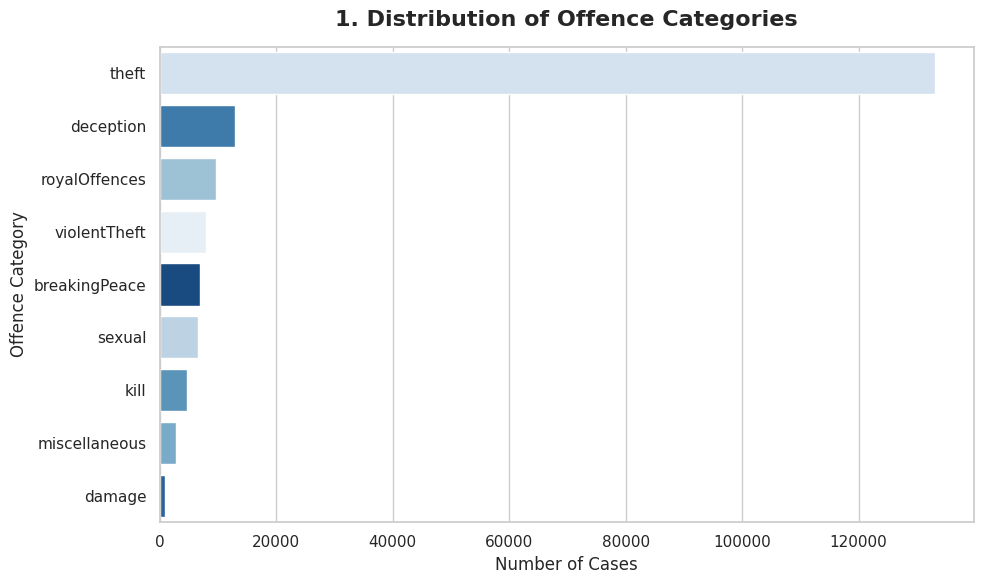

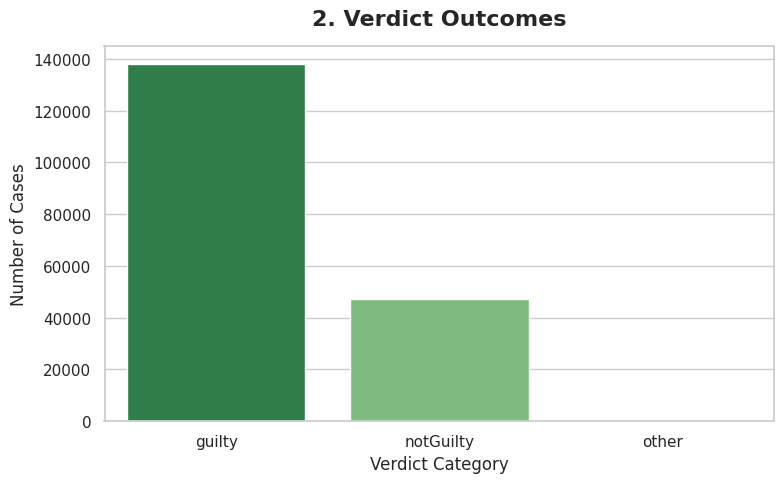

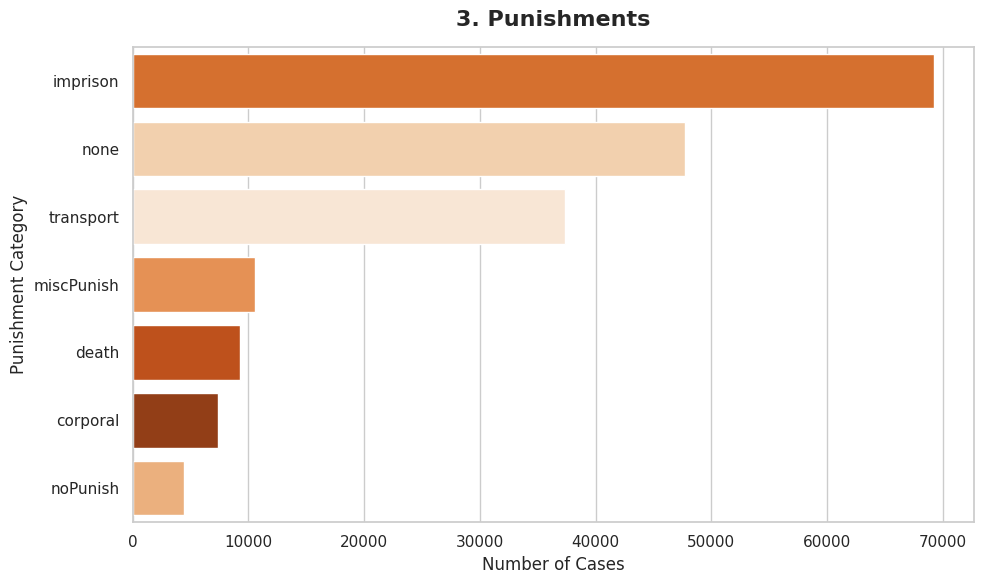

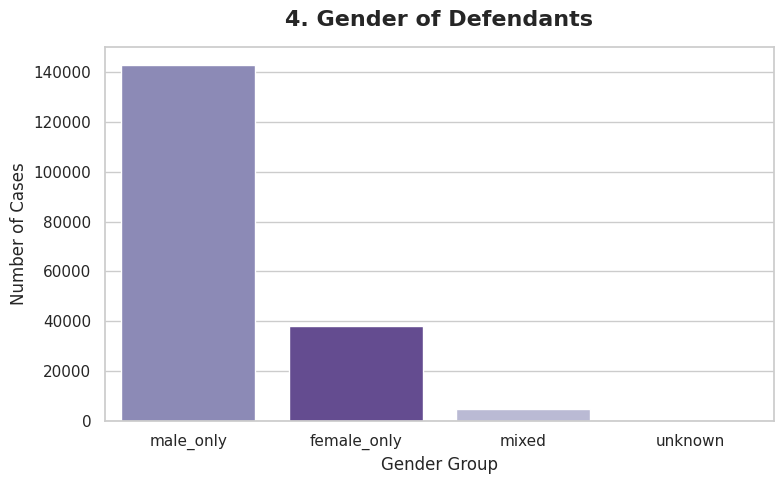

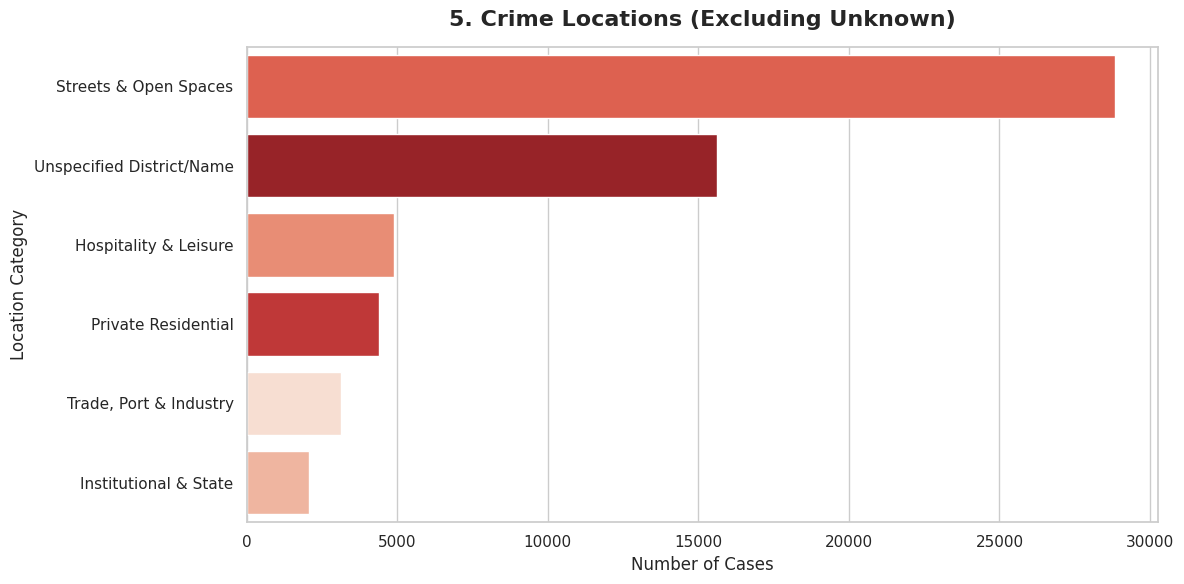

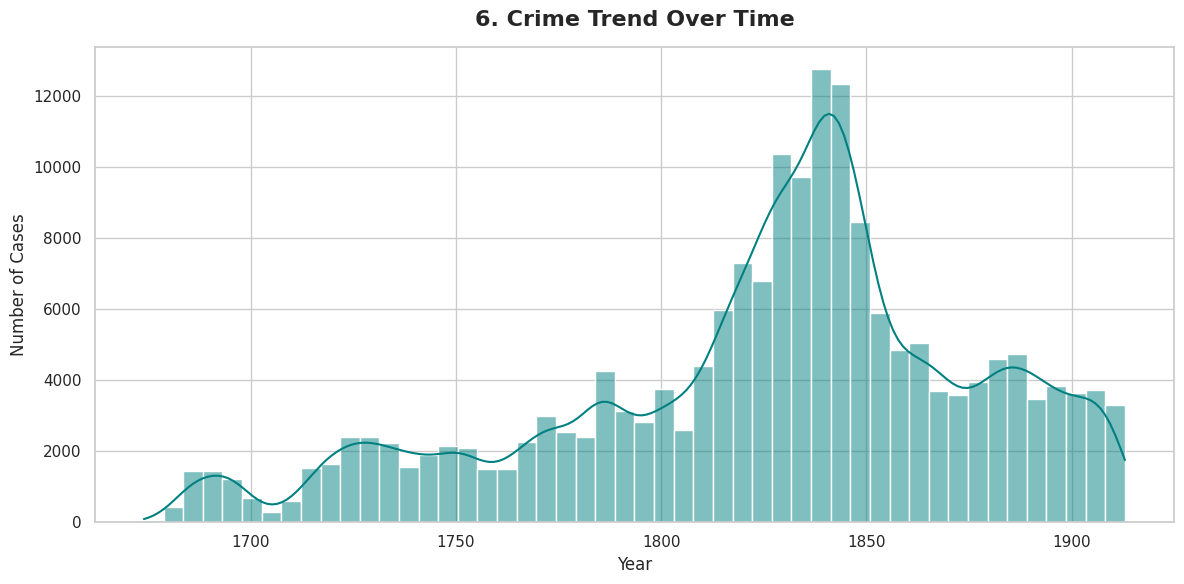

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่า Theme หลัก
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# กราฟที่ 1: Offence Category
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, y='offenceCategory',
              order=df_clean['offenceCategory'].value_counts().index,
              hue='offenceCategory', legend=False,  # แก้ไข FutureWarning
              palette='Blues_r')
plt.title('1. Distribution of Offence Categories', fontsize=16, fontweight='bold', pad=15) # เอาภาษาไทยออก
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Offence Category', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 2: Verdict Category
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='verdictCategory',
              order=df_clean['verdictCategory'].value_counts().index,
              hue='verdictCategory', legend=False,
              palette='Greens_r')
plt.title('2. Verdict Outcomes', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Verdict Category', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 3: Punishment Category
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, y='punishmentCategory',
              order=df_clean['punishmentCategory'].value_counts().index,
              hue='punishmentCategory', legend=False,
              palette='Oranges_r')
plt.title('3. Punishments', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Punishment Category', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 4: Gender Group
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='gender_group',
              order=df_clean['gender_group'].value_counts().index,
              hue='gender_group', legend=False,
              palette='Purples_r')
plt.title('4. Gender of Defendants', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gender Group', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 5: Location Group (กรอง Unknown ออก)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
df_loc = df_clean[df_clean['location_final_pro'] != 'Unknown']
sns.countplot(data=df_loc, y='location_final_pro',
              order=df_loc['location_final_pro'].value_counts().index,
              hue='location_final_pro', legend=False,
              palette='Reds_r')
plt.title('5. Crime Locations (Excluding Unknown)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Location Category', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 6: Year Trend
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x='year', bins=50, kde=True, color='teal')
plt.title('6. Crime Trend Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.tight_layout()
plt.show()

# Check data quality

In [ ]:
print("Data sample : ")
print(df_clean.sample(10))

Data sample : 
       offenceCategory offenceSubcategory verdictCategory punishmentCategory  \
125591           theft      housebreaking          guilty           imprison   
188750           theft     theftFromPlace          guilty           imprison   
51108            theft       grandLarceny          guilty         miscPunish   
87535            theft      simpleLarceny          guilty          transport   
166548       deception            forgery          guilty           imprison   
86155            theft      simpleLarceny          guilty           corporal   
11598            theft       grandLarceny          guilty          transport   
157379           theft           burglary          guilty           imprison   
29410            theft       grandLarceny          guilty          transport   
60464            theft       grandLarceny          guilty           corporal   

                                          crime_locations  \
125591                                     

In [ ]:
print("Data info : ")
df_clean.info()

Data info : 
<class 'pandas.core.frame.DataFrame'>
Index: 186041 entries, 9 to 197750
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        186041 non-null  category
 1   offenceSubcategory     186041 non-null  category
 2   verdictCategory        186041 non-null  category
 3   punishmentCategory     186041 non-null  category
 4   crime_locations        186041 non-null  object  
 5   defendant_names        186041 non-null  object  
 6   num_defendants         186041 non-null  int64   
 7   num_victims            186041 non-null  int64   
 8   num_offences           186041 non-null  int64   
 9   num_verdicts           186041 non-null  int64   
 10  num_punishments        186041 non-null  int64   
 11  year                   186041 non-null  int64   
 12  month                  186041 non-null  int64   
 13  day                    186041 non-null  int64   
 14  num_male    

In [ ]:
print("Data describe : ")
print(df_clean.describe())

Data describe : 
       num_defendants    num_victims   num_offences   num_verdicts  \
count   186041.000000  186041.000000  186041.000000  186041.000000   
mean         1.203090       1.024301       1.058041       1.096027   
std          0.580268       0.712095       0.308878       0.357789   
min          1.000000       0.000000       1.000000       1.000000   
25%          1.000000       1.000000       1.000000       1.000000   
50%          1.000000       1.000000       1.000000       1.000000   
75%          1.000000       1.000000       1.000000       1.000000   
max         26.000000      35.000000      15.000000      12.000000   

       num_punishments           year          month            day  \
count    186041.000000  186041.000000  186041.000000  186041.000000   
mean          0.853027    1824.492762       6.440978      14.891922   
std           0.613799      52.088195       3.498458       8.287560   
min           0.000000    1674.000000       1.000000       1.000000 

In [ ]:
# 1. ระบุรายชื่อคอลัมน์ที่ต้องการลบ
cols_to_drop = ['crime_locations', 'defendant_names', 'location_group_final']

# 2. ทำการลบคอลัมน์ (axis=1 หมายถึงลบแนวคอลัมน์)
df_clean = df_clean.drop(columns=cols_to_drop)

# 3. (Bonus) แปลง location_final_pro เป็น category เพื่อประหยัด Memory
df_clean['location_final_pro'] = df_clean['location_final_pro'].astype('category')

# เช็กผลลัพธ์โครงสร้างข้อมูลใหม่
print("✅ ลบคอลัมน์เสร็จสิ้น! โครงสร้างข้อมูลล่าสุดของคุณคือ:")
print("-" * 50)
df_clean.info()

✅ ลบคอลัมน์เสร็จสิ้น! โครงสร้างข้อมูลล่าสุดของคุณคือ:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 186041 entries, 9 to 197750
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        186041 non-null  category
 1   offenceSubcategory     186041 non-null  category
 2   verdictCategory        186041 non-null  category
 3   punishmentCategory     186041 non-null  category
 4   num_defendants         186041 non-null  int64   
 5   num_victims            186041 non-null  int64   
 6   num_offences           186041 non-null  int64   
 7   num_verdicts           186041 non-null  int64   
 8   num_punishments        186041 non-null  int64   
 9   year                   186041 non-null  int64   
 10  month                  186041 non-null  int64   
 11  day                    186041 non-null  int64   
 12  num_male               18604

In [ ]:
# 1. กำจัดข้อมูลซ้ำ 79 แถวสุดท้าย
df_clean = df_clean.drop_duplicates()

print(f"✅ ล้างข้อมูลซ้ำเรียบร้อย! ข้อมูลสุดท้ายมีจำนวน: {len(df_clean):,} แถว")

✅ ล้างข้อมูลซ้ำเรียบร้อย! ข้อมูลสุดท้ายมีจำนวน: 185,962 แถว


In [ ]:
import pandas as pd
import numpy as np

def check_data_health(df):
    print("="*50)
    print(" 🏥 DATA HEALTH CHECK REPORT (รายงานสุขภาพข้อมูล)")
    print("="*50)

    # 1. เช็กขนาดข้อมูล (Shape)
    print(f"📊 1. ภาพรวมข้อมูล:")
    print(f"   - จำนวนแถว (Rows): {df.shape[0]:,}")
    print(f"   - จำนวนคอลัมน์ (Columns): {df.shape[1]}")

    # 2. เช็กค่าว่าง (Missing Values)
    total_missing = df.isnull().sum().sum()
    print(f"\n🔍 2. การตรวจสอบค่าว่าง (Missing Values):")
    if total_missing == 0:
        print("   - ✅ ผ่านฉลุย! (ไม่พบค่าว่างเลยแม้แต่ช่องเดียว)")
    else:
        print(f"   - ❌ พบค่าว่างทั้งหมด {total_missing:,} จุด (ควรกลับไปเช็ก df.isnull().sum())")

    # 3. เช็กข้อมูลซ้ำซ้อน (Duplicates)
    # สมมติว่าเราเอาชื่อจำเลยและคอลัมน์อื่นๆ มาเช็กร่วมด้วย
    dupes = df.duplicated().sum()
    print(f"\n👯 3. การตรวจสอบข้อมูลซ้ำ (Exact Duplicates):")
    if dupes == 0:
         print("   - ✅ ผ่าน! (ไม่มีข้อมูลแถวไหนหน้าตาเหมือนกันเป๊ะ 100%)")
    else:
         print(f"   - ⚠️ พบข้อมูลซ้ำ {dupes:,} แถว (แนะนำให้ใช้ df.drop_duplicates())")

    # 4. เช็ก Logic Error (คำตัดสิน vs บทลงโทษ)
    print(f"\n⚖️ 4. การตรวจสอบตรรกะ (Logic Check):")
    logic_err = len(df[(df['verdictCategory'] == 'notGuilty') & (df['punishmentCategory'] != 'none')])
    if logic_err == 0:
        print("   - ✅ ผ่าน! (ไม่มีใครที่ศาลตัดสินว่า 'ไม่ผิด' แต่ดันโดน 'ลงโทษ')")
    else:
        print(f"   - ❌ พบข้อมูลขัดแย้ง {logic_err} แถว (คนไม่ผิดแต่โดนลงโทษ)")

    # 5. เช็กความสะอาดของกลุ่มข้อมูล (Categorical Sanity)
    print(f"\n🏷️ 5. จำนวนหมวดหมู่ในคอลัมน์หลัก (Categorical Sanity):")
    cat_cols = ['offenceCategory', 'offenceSubcategory', 'verdictCategory', 'punishmentCategory', 'location_final_pro']
    for col in cat_cols:
        if col in df.columns:
            n_unique = df[col].nunique()
            print(f"   - {col}: มี {n_unique} หมวดหมู่")
            if n_unique > 50:
                print(f"     ⚠️ คำเตือน: หมวดหมู่เยอะเกินไป อาจทำให้กราฟรก (มีหมวดหมู่ย่อยยุบยับ)")

    # 6. เช็กค่าผิดปกติของตัวเลข (Numerical Outliers)
    print(f"\n🔢 6. ตรวจสอบขอบเขตตัวเลข (Min-Max Sanity):")
    num_cols = ['year', 'num_defendants', 'num_victims']
    for col in num_cols:
        if col in df.columns:
            print(f"   - {col}: ค่าน้อยสุด = {df[col].min()}, ค่ามากสุด = {df[col].max()}")

    print("="*50)
    print(" 🎉 ตรวจสอบเสร็จสิ้น!")
    print("="*50)

# --- วิธีเรียกใช้งาน ---
check_data_health(df_clean)

 🏥 DATA HEALTH CHECK REPORT (รายงานสุขภาพข้อมูล)
📊 1. ภาพรวมข้อมูล:
   - จำนวนแถว (Rows): 185,962
   - จำนวนคอลัมน์ (Columns): 17

🔍 2. การตรวจสอบค่าว่าง (Missing Values):
   - ✅ ผ่านฉลุย! (ไม่พบค่าว่างเลยแม้แต่ช่องเดียว)

👯 3. การตรวจสอบข้อมูลซ้ำ (Exact Duplicates):
   - ✅ ผ่าน! (ไม่มีข้อมูลแถวไหนหน้าตาเหมือนกันเป๊ะ 100%)

⚖️ 4. การตรวจสอบตรรกะ (Logic Check):
   - ✅ ผ่าน! (ไม่มีใครที่ศาลตัดสินว่า 'ไม่ผิด' แต่ดันโดน 'ลงโทษ')

🏷️ 5. จำนวนหมวดหมู่ในคอลัมน์หลัก (Categorical Sanity):
   - offenceCategory: มี 9 หมวดหมู่
   - offenceSubcategory: มี 24 หมวดหมู่
   - verdictCategory: มี 3 หมวดหมู่
   - punishmentCategory: มี 7 หมวดหมู่
   - location_final_pro: มี 7 หมวดหมู่

🔢 6. ตรวจสอบขอบเขตตัวเลข (Min-Max Sanity):
   - year: ค่าน้อยสุด = 1674, ค่ามากสุด = 1913
   - num_defendants: ค่าน้อยสุด = 1, ค่ามากสุด = 26
   - num_victims: ค่าน้อยสุด = 0, ค่ามากสุด = 35
 🎉 ตรวจสอบเสร็จสิ้น!


# Outliers

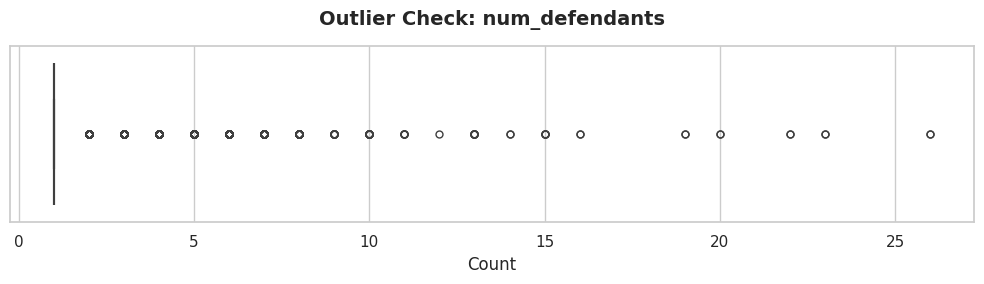

------------------------------------------------------------


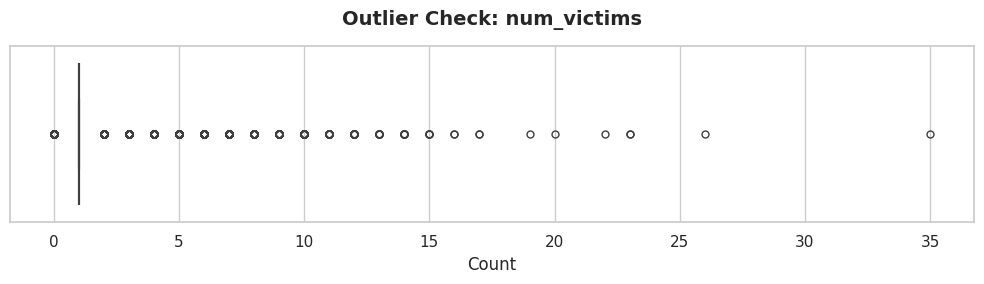

------------------------------------------------------------


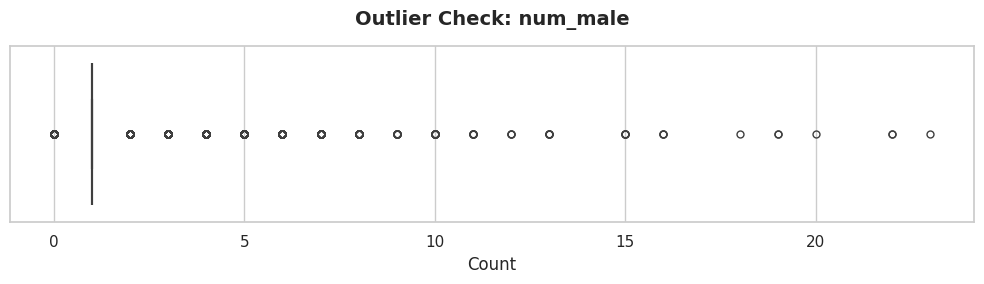

------------------------------------------------------------


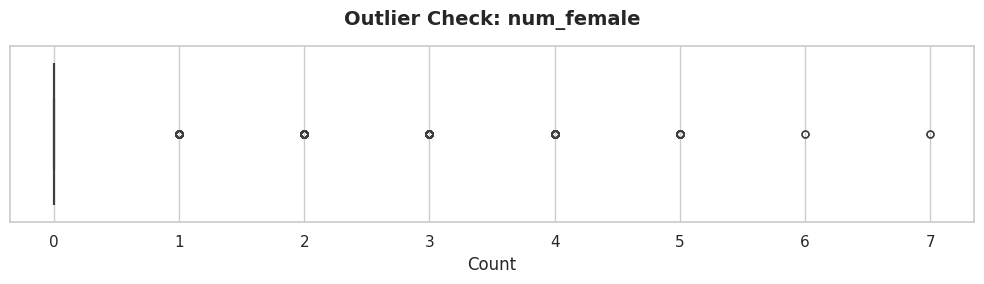

------------------------------------------------------------


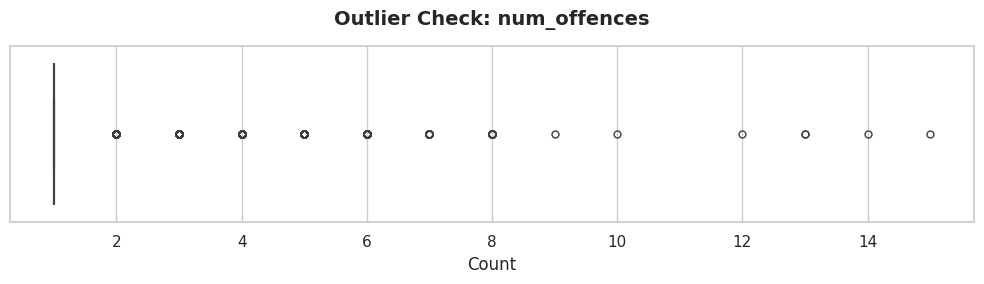

------------------------------------------------------------


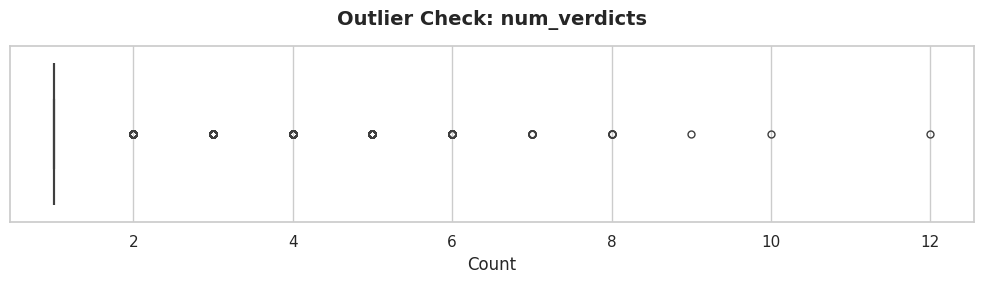

------------------------------------------------------------


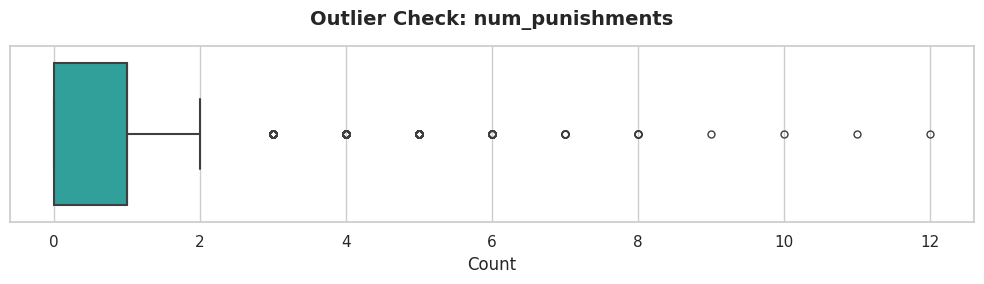

------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. กำหนดคอลัมน์ตัวเลขที่ต้องการตรวจสอบ
expected_cols = ['num_defendants', 'num_victims', 'num_male', 'num_female',
                 'num_offences', 'num_verdicts', 'num_punishments']

# กรองเฉพาะคอลัมน์ที่ยังอยู่ใน df_clean (เผื่อคุณลบบางอันไปแล้ว)
cols_to_plot = [col for col in expected_cols if col in df_clean.columns]

# 2. ตั้งค่า Theme หลัก
sns.set_theme(style="whitegrid")

# 3. วนลูปสร้างกราฟแยกทีละรูป
for col in cols_to_plot:
    plt.figure(figsize=(10, 3)) # ปรับให้กราฟกว้างแนวนอน จะได้เห็น Outlier ชัดๆ

    # วาด Boxplot
    sns.boxplot(x=df_clean[col], color='lightseagreen', fliersize=5, linewidth=1.5)

    # ตกแต่งกราฟ
    plt.title(f'Outlier Check: {col}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Count', fontsize=12)

    # แสดงกราฟทีละรูป
    plt.tight_layout()
    plt.show()
    print("-" * 60) # ตีเส้นคั่นระหว่างกราฟ

In [ ]:
# สร้างลิสต์คอลัมน์ที่ต้องการดู
cols_to_check = ['num_defendants', 'num_victims', 'num_male', 'num_female',
                 'num_offences', 'num_verdicts', 'num_punishments']
for col in cols_to_check:
    if col in df_clean.columns:
        print(f"\n📊 [ {col} ] - Distribution:")
        print("-" * 45)

        # คำนวณจำนวน (Count) และเปอร์เซ็นต์ (Percentage)
        counts = df_clean[col].value_counts().sort_index()
        percents = df_clean[col].value_counts(normalize=True).sort_index() * 100

        # รวมเป็น DataFrame เพื่อความสวยงาม
        dist_df = pd.DataFrame({
            'จำนวนคดี (Cases)': counts,
            'เปอร์เซ็นต์ (%)': percents.map('{:.2f}%'.format) # ปัดเศษ 2 ตำแหน่งและเติม %
        })

        # แสดงผล 10 อันดับแรก (ส่วนใหญ่ค่าจะกองอยู่แค่ 1-5 อันดับแรก)
        print(dist_df.head(10))
        print("-" * 45)


📊 [ num_defendants ] - Distribution:
---------------------------------------------
                จำนวนคดี (Cases) เปอร์เซ็นต์ (%)
num_defendants                                  
1                         157123          84.49%
2                          22773          12.25%
3                           4502           2.42%
4                           1003           0.54%
5                            345           0.19%
6                             83           0.04%
7                             49           0.03%
8                             26           0.01%
9                             11           0.01%
10                            14           0.01%
---------------------------------------------

📊 [ num_victims ] - Distribution:
---------------------------------------------
             จำนวนคดี (Cases) เปอร์เซ็นต์ (%)
num_victims                                  
0                       25489          13.71%
1                      139436          74.98%
2                

In [ ]:
import numpy as np

# --- 🎯 1. ฟังก์ชันสำหรับการจัดกลุ่ม (เหมือนเดิม) ---
def bin_defendants(n):
    if n == 1: return '1. Solo'
    elif 2 <= n <= 4: return '2. Small Group'
    else: return '3. Gang/Riot'

def bin_victims(n):
    if n == 0: return '0. None'
    elif n == 1: return '1. Single'
    else: return '2. Multiple'

def bin_multi(n):
    if n <= 1: return '1. Single'
    else: return '2. Multiple'

def bin_punishments(n):
    if n == 0: return '0. None'
    elif n == 1: return '1. Single'
    else: return '2. Multiple'

# --- 🚀 2. เริ่มต้นประมวลผลแยกสาย (เพิ่ม Flagging) ---

cols_to_cap = ['num_defendants', 'num_victims', 'num_male', 'num_female',
                'num_offences', 'num_verdicts', 'num_punishments']

print("🛠️ กำลังสร้าง Feature ใหม่ (AI Capping + Story Binning + Mass Crime Flag)...")

for col in cols_to_cap:
    if col in df_clean.columns:
        # 🟢 สาย AI: Capping
        upper_limit = df_clean[col].quantile(0.99)
        new_col_ai = f"{col}_ai"

        # [NEW] ก่อนจะ Cap เราแอบทำ Flag ไว้ก่อน (เฉพาะ num_defendants)
        if col == 'num_defendants':
            # ปักธง 1 ถ้าจำนวนคนเกิน 99th Percentile (คดีใหญ่)
            df_clean['is_mass_crime'] = (df_clean[col] > upper_limit).astype(int)

        # ทำ Capping ตามปกติ
        df_clean[new_col_ai] = np.where(df_clean[col] > upper_limit, upper_limit, df_clean[col])

        # 🔵 สาย Story: Binning (เหมือนเดิม)
        if col == 'num_defendants':
            df_clean['defendants_story'] = df_clean[col].apply(bin_defendants)
        elif col == 'num_victims':
            df_clean['victims_story'] = df_clean[col].apply(bin_victims)
        elif col in ['num_offences', 'num_verdicts']:
            df_clean[f"{col.replace('num_', '')}_story"] = df_clean[col].apply(bin_multi)
        elif col == 'num_punishments':
            df_clean['punishments_story'] = df_clean[col].apply(bin_punishments)

print("✅ สร้าง 'ทางแยกข้อมูล' และ 'ธงคดีใหญ่' เสร็จสมบูรณ์!")
print("-" * 30)

# --- 🧐 3. ส่องผลลัพธ์ ---
# เพิ่ม is_mass_crime เข้ามาในคอลัมน์ที่จะโชว์ด้วย
cols_to_show = ['num_defendants', 'num_defendants_ai', 'is_mass_crime', 'defendants_story']
display(df_clean[df_clean['num_defendants'] > 4][cols_to_show].head(10)) # โชว์เฉพาะพวกคดีใหญ่ๆ จะได้เห็นธง

🛠️ กำลังสร้าง Feature ใหม่ (AI Capping + Story Binning + Mass Crime Flag)...
✅ สร้าง 'ทางแยกข้อมูล' และ 'ธงคดีใหญ่' เสร็จสมบูรณ์!
------------------------------


,num_defendants,num_defendants_ai,is_mass_crime,defendants_story
506,7,3.0,1,3. Gang/Riot
866,10,3.0,1,3. Gang/Riot
869,5,3.0,1,3. Gang/Riot
870,5,3.0,1,3. Gang/Riot
1030,5,3.0,1,3. Gang/Riot
1249,6,3.0,1,3. Gang/Riot
1544,5,3.0,1,3. Gang/Riot
1895,5,3.0,1,3. Gang/Riot
2155,5,3.0,1,3. Gang/Riot
2580,10,3.0,1,3. Gang/Riot


In [ ]:
import pandas as pd

# 1. ดูโครงสร้างและประเภทข้อมูลล่าสุด (เช็ก Memory Usage ด้วย)
print("📂 [1/4] ข้อมูลภาพรวมและโครงสร้างล่าสุด:")
print("-" * 50)
df_clean.info()

# 2. เปรียบเทียบสถิติสาย Raw vs สาย AI (ดูผลของการ Capping)
print("\n📊 [2/4] สถิติเปรียบเทียบ (Raw vs Capped for AI):")
print("-" * 50)
num_cols_compare = [col for col in df_clean.columns if '_ai' in col or col.startswith('num_')]
# เลือกเฉพาะคอลัมน์คู่ขนานมาเทียบกัน
display(df_clean[num_cols_compare].describe().loc[['min', 'max', 'mean', 'std']])

# 3. ตรวจสอบสาย Story และ Flag (ความถูกต้องของการจัดกลุ่ม)
print("\n🚩 [3/4] ตรวจสอบการกระจายตัวของ 'ธงคดีใหญ่' และ 'กลุ่มเล่าเรื่อง':")
print("-" * 50)
for col in ['is_mass_crime', 'defendants_story', 'victims_story']:
    if col in df_clean.columns:
        print(f"\n--- {col} ---")
        counts = df_clean[col].value_counts()
        percents = df_clean[col].value_counts(normalize=True) * 100
        print(pd.DataFrame({'Count': counts, 'Percentage (%)': percents.map('{:.2f}%'.format)}))

# 4. ส่องดูความสัมพันธ์แบบข้ามสาย (The Deep Look)
# สุ่มมา 10 แถวเพื่อดูว่าแต่ละแถวมันแปลงค่าถูกต้องไหม
print("\n🔍 [4/4] สุ่มตัวอย่างข้อมูล 10 แถว (เช็กความสัมพันธ์ Raw -> AI -> Story):")
print("-" * 50)
check_cols = ['num_defendants', 'num_defendants_ai', 'is_mass_crime', 'defendants_story',
              'num_victims', 'num_victims_ai', 'victims_story']
print(display(df_clean[check_cols].sample(10)))

📂 [1/4] ข้อมูลภาพรวมและโครงสร้างล่าสุด:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 185962 entries, 9 to 197750
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        185962 non-null  category
 1   offenceSubcategory     185962 non-null  category
 2   verdictCategory        185962 non-null  category
 3   punishmentCategory     185962 non-null  category
 4   num_defendants         185962 non-null  int64   
 5   num_victims            185962 non-null  int64   
 6   num_offences           185962 non-null  int64   
 7   num_verdicts           185962 non-null  int64   
 8   num_punishments        185962 non-null  int64   
 9   year                   185962 non-null  int64   
 10  month                  185962 non-null  int64   
 11  day                    185962 non-null  int64   
 12  num_male               185962 non-null  in

,num_defendants,num_victims,num_offences,num_verdicts,num_punishments,num_male,num_female,num_defendants_ai,num_victims_ai,num_male_ai,num_female_ai,num_offences_ai,num_verdicts_ai,num_punishments_ai
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,26.000000,35.000000,15.000000,12.000000,12.000000,23.000000,7.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000
mean,1.203074,1.024279,1.058049,1.096057,0.853131,0.945623,0.256638,1.187700,1.003775,0.934653,0.253460,1.045988,1.092600,0.840435
std,0.580296,0.712187,0.308918,0.357847,0.613791,0.693630,0.499239,0.466593,0.577343,0.623927,0.483238,0.209459,0.328139,0.570450



🚩 [3/4] ตรวจสอบการกระจายตัวของ 'ธงคดีใหญ่' และ 'กลุ่มเล่าเรื่อง':
--------------------------------------------------

--- is_mass_crime ---
                Count Percentage (%)
is_mass_crime                       
0              184398         99.16%
1                1564          0.84%

--- defendants_story ---
                   Count Percentage (%)
defendants_story                       
1. Solo           157123         84.49%
2. Small Group     28278         15.21%
3. Gang/Riot         561          0.30%

--- victims_story ---
                Count Percentage (%)
victims_story                       
1. Single      139436         74.98%
0. None         25489         13.71%
2. Multiple     21037         11.31%

🔍 [4/4] สุ่มตัวอย่างข้อมูล 10 แถว (เช็กความสัมพันธ์ Raw -> AI -> Story):
--------------------------------------------------


,num_defendants,num_defendants_ai,is_mass_crime,defendants_story,num_victims,num_victims_ai,victims_story
154846,1,1.0,0,1. Solo,1,1.0,1. Single
52765,1,1.0,0,1. Solo,3,3.0,2. Multiple
185392,1,1.0,0,1. Solo,0,0.0,0. None
139558,1,1.0,0,1. Solo,2,2.0,2. Multiple
72421,1,1.0,0,1. Solo,1,1.0,1. Single
122965,1,1.0,0,1. Solo,2,2.0,2. Multiple
128152,1,1.0,0,1. Solo,1,1.0,1. Single
169184,3,3.0,0,2. Small Group,1,1.0,1. Single
143782,1,1.0,0,1. Solo,1,1.0,1. Single
18313,1,1.0,0,1. Solo,1,1.0,1. Single


None


In [ ]:
# 1. รายชื่อคอลัมน์ตัวเลขที่เราต้องการแทนที่ด้วยค่าที่ Cap แล้ว
target_cols = ['num_defendants', 'num_victims', 'num_male', 'num_female',
               'num_offences', 'num_verdicts', 'num_punishments']

print("🔄 กำลังแทนที่ข้อมูลดิบด้วยข้อมูลที่คลีนแล้ว (Capped Data)...")

for col in target_cols:
    ai_col = f"{col}_ai"
    if ai_col in df_clean.columns:
        # แทนที่ค่าเดิมด้วยค่าที่ผ่านการทำ Capping มาแล้ว
        df_clean[col] = df_clean[ai_col]
        # ลบคอลัมน์ _ai ทิ้งเพราะเราได้ข้อมูลมาอยู่ในชื่อเดิมแล้ว
        df_clean.drop(columns=[ai_col], inplace=True)
        print(f"✅ แทนที่และลบ: {ai_col} ➡️ {col}")

print("-" * 50)
print("✨ ตอนนี้คอลัมน์ดั้งเดิมของคุณคือข้อมูลที่ 'Ready for AI' เรียบร้อยแล้วครับ!")

🔄 กำลังแทนที่ข้อมูลดิบด้วยข้อมูลที่คลีนแล้ว (Capped Data)...
✅ แทนที่และลบ: num_defendants_ai ➡️ num_defendants
✅ แทนที่และลบ: num_victims_ai ➡️ num_victims
✅ แทนที่และลบ: num_male_ai ➡️ num_male
✅ แทนที่และลบ: num_female_ai ➡️ num_female
✅ แทนที่และลบ: num_offences_ai ➡️ num_offences
✅ แทนที่และลบ: num_verdicts_ai ➡️ num_verdicts
✅ แทนที่และลบ: num_punishments_ai ➡️ num_punishments
--------------------------------------------------
✨ ตอนนี้คอลัมน์ดั้งเดิมของคุณคือข้อมูลที่ 'Ready for AI' เรียบร้อยแล้วครับ!


In [ ]:
# 1. เช็กโครงสร้างและประเภทข้อมูล
print("📂 [1/3] โครงสร้างข้อมูลล่าสุด (Clean & Professional):")
print("-" * 50)
df_clean.info()

# 2. เช็กค่าทางสถิติ (คุณจะพบว่าค่า Max สวยงามมาก ไม่โดดไปไกลแล้ว)
print("\n📊 [2/3] สถิติคอลัมน์ตัวเลข (ตรวจสอบว่า Max เปลี่ยนไปตามที่เราต้องการไหม):")
print("-" * 50)
num_cols = ['num_defendants', 'num_victims', 'num_male', 'num_female',
            'num_offences', 'num_verdicts', 'num_punishments']
display(df_clean[num_cols].describe().loc[['min', 'max', 'mean', 'std']])

# 3. ส่องดูข้อมูล 5 แถวสุดท้าย (เช็กว่าคอลัมน์ _ai หายไปแล้ว และเหลือคอลัมน์ Story/Flag)
print("\n👀 [3/3] สุ่มส่องตัวอย่างข้อมูลล่าสุด:")
print("-" * 50)
# เลือกคอลัมน์ที่เป็น Key สำคัญมาโชว์
key_cols = ['year', 'offenceCategory', 'num_defendants', 'is_mass_crime', 'defendants_story', 'verdictCategory']
display(df_clean[key_cols].tail(5))

📂 [1/3] โครงสร้างข้อมูลล่าสุด (Clean & Professional):
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 185962 entries, 9 to 197750
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        185962 non-null  category
 1   offenceSubcategory     185962 non-null  category
 2   verdictCategory        185962 non-null  category
 3   punishmentCategory     185962 non-null  category
 4   num_defendants         185962 non-null  float64 
 5   num_victims            185962 non-null  float64 
 6   num_offences           185962 non-null  float64 
 7   num_verdicts           185962 non-null  float64 
 8   num_punishments        185962 non-null  float64 
 9   year                   185962 non-null  int64   
 10  month                  185962 non-null  int64   
 11  day                    185962 non-null  int64   
 12  num_male               18596

,num_defendants,num_victims,num_male,num_female,num_offences,num_verdicts,num_punishments
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000
mean,1.187700,1.003775,0.934653,0.253460,1.045988,1.092600,0.840435
std,0.466593,0.577343,0.623927,0.483238,0.209459,0.328139,0.570450



👀 [3/3] สุ่มส่องตัวอย่างข้อมูลล่าสุด:
--------------------------------------------------


,year,offenceCategory,num_defendants,is_mass_crime,defendants_story,verdictCategory
197746,1913,breakingPeace,1.0,0,1. Solo,guilty
197747,1913,sexual,1.0,0,1. Solo,guilty
197748,1913,kill,2.0,0,2. Small Group,notGuilty
197749,1913,sexual,1.0,0,1. Solo,guilty
197750,1913,damage,1.0,0,1. Solo,guilty


In [ ]:
# 1. ค้นหาคอลัมน์ที่เป็นสาย Story (ลงท้ายด้วย _story)
story_cols = [col for col in df_clean.columns if '_story' in col]

print(f"🔄 กำลังแปลง {len(story_cols)} คอลัมน์ให้เป็น Category...")

for col in story_cols:
    if col in df_clean.columns:
        # แปลงเป็น category
        df_clean[col] = df_clean[col].astype('category')
        print(f"✅ แปลงสำเร็จ: {col}")

print("-" * 50)

# 2. ตรวจสอบ Memory Usage อีกครั้ง
new_memory = df_clean.memory_usage().sum() / 1024**2
print(f"💾 Memory Usage ล่าสุด: {new_memory:.2f} MB")
print("-" * 50)

# แสดงผล 5 แถวแรกของคอลัมน์ที่แปลงแล้ว
display(df_clean[story_cols].head())

🔄 กำลังแปลง 5 คอลัมน์ให้เป็น Category...
✅ แปลงสำเร็จ: defendants_story
✅ แปลงสำเร็จ: victims_story
✅ แปลงสำเร็จ: offences_story
✅ แปลงสำเร็จ: verdicts_story
✅ แปลงสำเร็จ: punishments_story
--------------------------------------------------
💾 Memory Usage ล่าสุด: 20.40 MB
--------------------------------------------------


,defendants_story,victims_story,offences_story,verdicts_story,punishments_story
9,1. Solo,0. None,1. Single,1. Single,1. Single
10,1. Solo,2. Multiple,2. Multiple,1. Single,1. Single
14,1. Solo,0. None,1. Single,1. Single,1. Single
15,1. Solo,2. Multiple,2. Multiple,1. Single,1. Single
29,1. Solo,0. None,2. Multiple,2. Multiple,1. Single


In [ ]:
print(df_clean.info())
print(df_clean.sample(10))

<class 'pandas.core.frame.DataFrame'>
Index: 185962 entries, 9 to 197750
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   offenceCategory        185962 non-null  category
 1   offenceSubcategory     185962 non-null  category
 2   verdictCategory        185962 non-null  category
 3   punishmentCategory     185962 non-null  category
 4   num_defendants         185962 non-null  float64 
 5   num_victims            185962 non-null  float64 
 6   num_offences           185962 non-null  float64 
 7   num_verdicts           185962 non-null  float64 
 8   num_punishments        185962 non-null  float64 
 9   year                   185962 non-null  int64   
 10  month                  185962 non-null  int64   
 11  day                    185962 non-null  int64   
 12  num_male               185962 non-null  float64 
 13  num_female             185962 non-null  float64 
 14  gender_group           18

In [ ]:
target_cols = ['verdictCategory', 'punishmentCategory', 'verdicts_story', 'punishments_story']

for col in target_cols:
    print(f"\n⚖️ [ {col} ]")
    print("-" * 30)
    counts = df_clean[col].value_counts()
    percents = df_clean[col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percents.map('{:.2f}%'.format)}))


⚖️ [ verdictCategory ]
------------------------------


,Count,Percentage (%)
verdictCategory,,
guilty,138087,74.26%
notGuilty,47272,25.42%
other,603,0.32%



⚖️ [ punishmentCategory ]
------------------------------


,Count,Percentage (%)
punishmentCategory,,
imprison,69222,37.22%
none,47686,25.64%
transport,37353,20.09%
miscPunish,10550,5.67%
death,9316,5.01%
corporal,7403,3.98%
noPunish,4432,2.38%



⚖️ [ verdicts_story ]
------------------------------


,Count,Percentage (%)
verdicts_story,,
1. Single,170941,91.92%
2. Multiple,15021,8.08%



⚖️ [ punishments_story ]
------------------------------


,Count,Percentage (%)
punishments_story,,
1. Single,120713,64.91%
0. None,47461,25.52%
2. Multiple,17788,9.57%


In [ ]:
crime_cols = ['offenceCategory', 'location_final_pro', 'offences_story']

for col in crime_cols:
    print(f"\n🔍 [ {col} ]")
    print("-" * 30)
    # สำหรับ Category ที่เยอะๆ เราจะดูแค่ Top 10
    counts = df_clean[col].value_counts().head(10)
    percents = df_clean[col].value_counts(normalize=True).head(10) * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percents.map('{:.2f}%'.format)}))


🔍 [ offenceCategory ]
------------------------------


,Count,Percentage (%)
offenceCategory,,
theft,133066,71.56%
deception,12956,6.97%
royalOffences,9764,5.25%
violentTheft,7931,4.26%
breakingPeace,7023,3.78%
sexual,6619,3.56%
kill,4788,2.57%
miscellaneous,2864,1.54%
damage,951,0.51%



🔍 [ location_final_pro ]
------------------------------


,Count,Percentage (%)
location_final_pro,,
Unknown,127105,68.35%
Streets & Open Spaces,28777,15.47%
Unspecified District/Name,15605,8.39%
Hospitality & Leisure,4892,2.63%
Private Residential,4382,2.36%
"Trade, Port & Industry",3141,1.69%
Institutional & State,2060,1.11%



🔍 [ offences_story ]
------------------------------


,Count,Percentage (%)
offences_story,,
1. Single,177410,95.40%
2. Multiple,8552,4.60%


In [ ]:
ai_cols = ['num_defendants', 'num_victims', 'is_mass_crime', 'defendants_story', 'gender_group']

for col in ai_cols:
    print(f"\n🤖 [ {col} ]")
    print("-" * 30)
    counts = df_clean[col].value_counts().sort_index()
    percents = df_clean[col].value_counts(normalize=True).sort_index() * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percents.map('{:.2f}%'.format)}))


🤖 [ num_defendants ]
------------------------------


,Count,Percentage (%)
num_defendants,,
1.0,157123,84.49%
2.0,22773,12.25%
3.0,6066,3.26%



🤖 [ num_victims ]
------------------------------


,Count,Percentage (%)
num_victims,,
0.0,25489,13.71%
1.0,139436,74.98%
2.0,15883,8.54%
3.0,5154,2.77%



🤖 [ is_mass_crime ]
------------------------------


,Count,Percentage (%)
is_mass_crime,,
0,184398,99.16%
1,1564,0.84%



🤖 [ defendants_story ]
------------------------------


,Count,Percentage (%)
defendants_story,,
1. Solo,157123,84.49%
2. Small Group,28278,15.21%
3. Gang/Riot,561,0.30%



🤖 [ gender_group ]
------------------------------


,Count,Percentage (%)
gender_group,,
female_only,38178,20.53%
male_only,142902,76.84%
mixed,4837,2.60%
unknown,45,0.02%


# validation checklist

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
import pandas as pd
import numpy as np

def validate_data(data_clean):

    print("="*60)
    print("🔎 DATA VALIDATION REPORT")
    print("="*60)

    # -------------------------------------------------
    # 1️⃣ Structure Check
    # -------------------------------------------------
    print("\n1️⃣ STRUCTURE CHECK")

    if data_clean is None:
        print("❌ data_clean is None")
        return

    if not isinstance(data_clean, pd.DataFrame):
        print("❌ data_clean is not a DataFrame")
        return

    print("✅ DataFrame shape:", data_clean.shape)
    print("✅ Columns:", list(data_clean.columns))

    # duplicate columns
    if data_clean.columns.duplicated().sum() > 0:
        print("❌ Duplicate column names found")
    else:
        print("✅ No duplicate column names")

    # -------------------------------------------------
    # 2️⃣ Missing Values
    # -------------------------------------------------
    print("\n2️⃣ MISSING VALUES CHECK")
    missing = data_clean.isnull().sum()
    print(missing)

    if missing.sum() == 0:
        print("✅ No missing values")
    else:
        print("⚠️ Missing values detected")

    # -------------------------------------------------
    # 3️⃣ Duplicate Rows
    # -------------------------------------------------
    print("\n3️⃣ DUPLICATE ROWS CHECK")
    dup = data_clean.duplicated().sum()
    print("Duplicate rows:", dup)

    if dup == 0:
        print("✅ No duplicate rows")
    else:
        print("⚠️ Consider dropping duplicates")

    # -------------------------------------------------
    # 4️⃣ Numeric Range Check
    # -------------------------------------------------
    print("\n4️⃣ NUMERIC RANGE CHECK")

    numeric_cols = data_clean.select_dtypes(include=np.number).columns
    print(data_clean[numeric_cols].describe())

    # Logic checks
    logic_checks = []

    if "num_victims" in data_clean.columns:
        if (data_clean["num_victims"] < 0).any():
            logic_checks.append("❌ num_victims has negative values")

    if "num_offences" in data_clean.columns:
        if (data_clean["num_offences"] < 0).any():
            logic_checks.append("❌ num_offences has negative values")

    if "num_defendants" in data_clean.columns:
        if (data_clean["num_defendants"] < 0).any():
            logic_checks.append("❌ num_defendants has negative values")

    if "year" in data_clean.columns:
        if not data_clean["year"].between(1600, 2000).all():
            logic_checks.append("year outside expected Old Bailey range")

    if len(logic_checks) == 0:
        print("Numeric logic looks OK")
    else:
        for issue in logic_checks:
            print(issue)

    # -------------------------------------------------
    # Severity Index Check (Regression feature)
    # -------------------------------------------------
    print("SEVERITY INDEX CHECK")

    required_cols = {"num_victims", "num_offences", "num_defendants", "severity_index"}

    if required_cols.issubset(data_clean.columns):
        calc = (
            data_clean["num_victims"] +
            data_clean["num_offences"] +
            data_clean["num_defendants"]
        )
        mismatch = (calc != data_clean["severity_index"]).sum()

        if mismatch == 0:
            print("severity_index correctly calculated")
        else:
            print(f"severity_index mismatch in {mismatch} rows")
    else:
        print("severity_index check skipped (columns missing)")

    # -------------------------------------------------
    # Target Validation (Classification)
    # -------------------------------------------------
    print(" TARGET VARIABLE CHECK")

    if "punishmentCategory" in data_clean.columns:
        vc = data_clean["punishmentCategory"].value_counts(normalize=True)
        print(vc)

        if vc.min() < 0.01:
            print("⚠️ Severe class imbalance detected")
        else:
            print("✅ Class distribution looks reasonable")
    else:
        print("⚠️ punishmentCategory not found")

    # -------------------------------------------------
    # Time Series Validation
    # -------------------------------------------------
    print("\n7️⃣ TIME SERIES CHECK")

    if "year" in data_clean.columns:
        sorted_check = data_clean["year"].is_monotonic_increasing
        if sorted_check:
            print("✅ Year sorted")
        else:
            print("⚠️ Year not sorted. Consider sorting")

        print("Year range:", data_clean["year"].min(), "-", data_clean["year"].max())
    else:
        print("⚠️ year column not found")

    # -------------------------------------------------
    # Outlier Detection (IQR)
    # -------------------------------------------------
    print("\n8️⃣ OUTLIER CHECK (IQR METHOD)")

    for col in numeric_cols:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = data_clean[(data_clean[col] < Q1 - 1.5 * IQR) |
                              (data_clean[col] > Q3 + 1.5 * IQR)]

        print(f"{col}: {len(outliers)} potential outliers")

    print("\n" + "="*60)
    print("✅ VALIDATION COMPLETE")
    print("="*60)


# -------------------------------------------------
# RUN VALIDATION
# -------------------------------------------------
validate_data(df_clean)

🔎 DATA VALIDATION REPORT

1️⃣ STRUCTURE CHECK
✅ DataFrame shape: (185960, 23)
✅ Columns: ['offenceCategory', 'offenceSubcategory', 'verdictCategory', 'punishmentCategory', 'num_defendants', 'num_victims', 'num_offences', 'num_verdicts', 'num_punishments', 'year', 'month', 'day', 'num_male', 'num_female', 'gender_group', 'defendant_names_clean', 'location_final_pro', 'is_mass_crime', 'defendants_story', 'victims_story', 'offences_story', 'verdicts_story', 'punishments_story']
✅ No duplicate column names

2️⃣ MISSING VALUES CHECK
offenceCategory          0
offenceSubcategory       0
verdictCategory          0
punishmentCategory       0
num_defendants           0
num_victims              0
num_offences             0
num_verdicts             0
num_punishments          0
year                     0
month                    0
day                      0
num_male                 0
num_female               0
gender_group             0
defendant_names_clean    0
location_final_pro       0
is_mass

# Export cleaning data

In [ ]:
rename_dict = {

    # Crime info
    "offenceCategory": "crime_category",
    "offenceSubcategory": "crime_subcategory",

    # Court decision
    "verdictCategory": "verdict_category",
    "punishmentCategory": "punishment_category",

    # Counts
    "num_defendants": "defendant_count",
    "num_victims": "victim_count",
    "num_offences": "offence_count",
    "num_verdicts": "verdict_count",
    "num_punishments": "punishment_count",

    # Gender
    "num_male": "male_defendant_count",
    "num_female": "female_defendant_count",
    "gender_group": "defendant_gender_group",

    # Meta
    "defendant_names_clean": "defendant_names",
    "location_final_pro": "crime_location",
    "is_mass_crime": "mass_crime_flag",

    # Text summaries
    "defendants_story": "defendant_group_scale",
    "victims_story": "victim_scale",
    "offences_story": "offence_complexity",
    "verdicts_story": "verdict_pattern",
    "punishments_story": "punishment_severity_pattern"
}

df_clean = df_clean.rename(columns=rename_dict)

In [ ]:
# ต้องใช้ชื่อคอลัมน์ตัวจริงที่มีอยู่ใน Dataset ของคุณครับ
cols = [
    "defendant_group_scale",
    "victim_scale",
    "offence_complexity",
    "verdict_pattern",
    "punishment_severity_pattern"
]

# เช็คจำนวน Unique values รวมๆ ก่อน
print("=== จำนวนกลุ่ม (Unique Values) ในแต่ละคอลัมน์ ===")
print(df_clean[cols].nunique())
print("\n")

# วนลูปดูรายละเอียดว่าข้างในมีกลุ่มอะไรบ้าง และมีกี่คดี
for col in cols:
    print("="*50)
    print(f"Column: {col}")
    print("Unique count:", df_clean[col].nunique())
    print("-" * 20)
    print(df_clean[col].value_counts())

=== จำนวนกลุ่ม (Unique Values) ในแต่ละคอลัมน์ ===
defendant_group_scale          3
victim_scale                   3
offence_complexity             2
verdict_pattern                2
punishment_severity_pattern    3
dtype: int64


Column: defendant_group_scale
Unique count: 3
--------------------
defendant_group_scale
1. Solo           157121
2. Small Group     28278
3. Gang/Riot         561
Name: count, dtype: int64
Column: victim_scale
Unique count: 3
--------------------
victim_scale
1. Single      139436
0. None         25489
2. Multiple     21035
Name: count, dtype: int64
Column: offence_complexity
Unique count: 2
--------------------
offence_complexity
1. Single      177408
2. Multiple      8552
Name: count, dtype: int64
Column: verdict_pattern
Unique count: 2
--------------------
verdict_pattern
1. Single      170939
2. Multiple     15021
Name: count, dtype: int64
Column: punishment_severity_pattern
Unique count: 3
--------------------
punishment_severity_pattern
1. Single      1

In [ ]:
df_clean.to_csv("Sessions Paper Old Bailey.csv", index=False, encoding="utf-8")